# 🎛️ Optimisation Hyperparamètres Random Forest

Objectif : trouver la configuration RF qui optimise le compromis accuracy/fairness sur les embeddings du meilleur modèle.

In [1]:
# Cellule 1: Setup
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import product
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

if os.path.basename(os.getcwd()) != 'experiments':
    if os.path.exists(os.path.join(os.getcwd(), 'experiments')):
        os.chdir(os.path.join(os.getcwd(), 'experiments'))
print(f'📁 Répertoire: {os.getcwd()}')


📁 Répertoire: /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments


In [2]:
# Cellule 2: Charger données + embeddings du meilleur modèle
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): data.append(json.loads(line))
    return data

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_test   = le.transform(df_test['title'])
genders  = df_test['gender'].values

# Charger les embeddings du meilleur modèle (depuis notebook 03)
try:
    with open('best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Meilleur modèle embedding: {best_info["label"]} ({model_id})')
except FileNotFoundError:
    model_id = 'distilroberta-base'
    print(f'⚠️ best_embedding_model.json non trouvé — utilisation de {model_id}')

safe_name = model_id.replace('/', '_')
CACHE_DIR = Path('embedding_cache')

train_cache = list(CACHE_DIR.glob(f'{safe_name}_{len(df_train)}*.npy'))
test_cache  = list(CACHE_DIR.glob(f'{safe_name}_{len(df_test)}*.npy'))

if not train_cache or not test_cache:
    raise FileNotFoundError('Embeddings non trouvés. Lancez d abord 03_embedding_models_comparison.ipynb')

emb_train = np.load(train_cache[0])
emb_test  = np.load(test_cache[0])
print(f'✅ Embeddings chargés — train: {emb_train.shape}, test: {emb_test.shape}')


📦 Meilleur modèle embedding: DistilRoBERTa (distilroberta-base)
✅ Embeddings chargés — train: (8000, 768), test: (1000, 768)


In [3]:
# Cellule 3: Fonctions fairness (même que notebook 02, paramétrées)
def compute_fairness_metrics(y_true, y_pred, genders, le):
    groups = np.unique(genders)
    metrics = {'accuracy': accuracy_score(y_true, y_pred)}
    for g in groups:
        mask = genders == g
        metrics[f'accuracy_{g.lower()}'] = accuracy_score(y_true[mask], y_pred[mask])
    dp_gaps, eo_gaps, eqodds_gaps = [], [], []
    for class_id in range(len(le.classes_)):
        rates, tprs, fprs = {}, {}, {}
        for g in groups:
            mask = genders == g
            rates[g] = np.mean(y_pred[mask] == class_id)
            pm = mask & (y_true == class_id)
            nm = mask & (y_true != class_id)
            tprs[g] = np.mean(y_pred[pm] == class_id) if pm.sum() > 0 else 0
            fprs[g] = np.mean(y_pred[nm] == class_id) if nm.sum() > 0 else 0
        if len(groups) == 2:
            g0, g1 = groups[0], groups[1]
            dp_gaps.append(abs(rates[g0]-rates[g1]))
            eo_gaps.append(abs(tprs[g0]-tprs[g1]))
            eqodds_gaps.append(max(abs(tprs[g0]-tprs[g1]), abs(fprs[g0]-fprs[g1])))
    metrics['delta_dp']     = np.mean(dp_gaps)
    metrics['delta_eo']     = np.mean(eo_gaps)
    metrics['delta_eqodds'] = np.mean(eqodds_gaps)
    return metrics

print('✅ Fonctions fairness prêtes')


✅ Fonctions fairness prêtes


## 🔬 Grid Search

In [4]:
# Cellule 4: Grid Search accuracy + fairness
PARAM_GRID = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [10, 20, None],
    'min_samples_split': [2, 5, 10],
}

combinations = list(product(
    PARAM_GRID['n_estimators'],
    PARAM_GRID['max_depth'],
    PARAM_GRID['min_samples_split']
))

print(f'🔬 {len(combinations)} combinaisons à tester')
print('='*55)

grid_results = []

for n_est, max_d, min_s in tqdm(combinations, desc='Grid Search'):
    rf = RandomForestClassifier(
        n_estimators=n_est, max_depth=max_d,
        min_samples_split=min_s, random_state=42, n_jobs=-1
    )
    rf.fit(emb_train, y_train)
    preds = rf.predict(emb_test)

    fm = compute_fairness_metrics(y_test, preds, genders, le)
    fm.update({'n_estimators': n_est, 'max_depth': str(max_d), 'min_samples_split': min_s})
    grid_results.append(fm)

grid_df = pd.DataFrame(grid_results)
print(f'\n✅ Grid search terminé — {len(grid_df)} configurations évaluées')


🔬 27 combinaisons à tester


Grid Search: 100%|██████████| 27/27 [00:46<00:00,  1.73s/it]


✅ Grid search terminé — 27 configurations évaluées


## 📊 Analyse des Résultats

🏆 TOP 5 PAR ACCURACY:
 n_estimators max_depth  min_samples_split  accuracy  mean_gap
          200      None                  2     0.911  0.186473
          100      None                 10     0.905  0.183836
           50      None                  2     0.904  0.206085
          200      None                  5     0.903  0.209790
           50        20                  2     0.902  0.196303

⚖️ TOP 5 PAR FAIRNESS (gap minimum):
 n_estimators max_depth  min_samples_split  accuracy  mean_gap
          100        20                 10     0.899  0.172706
           50        10                 10     0.888  0.177012
          200        20                  2     0.900  0.179500
          100      None                  2     0.900  0.181137
           50      None                 10     0.897  0.181245

🎯 MEILLEUR COMPROMIS ACCURACY/FAIRNESS:
  n_estimators=100, max_depth=20, min_samples_split=10
  Accuracy: 0.8990 | Mean Gap: 0.1727


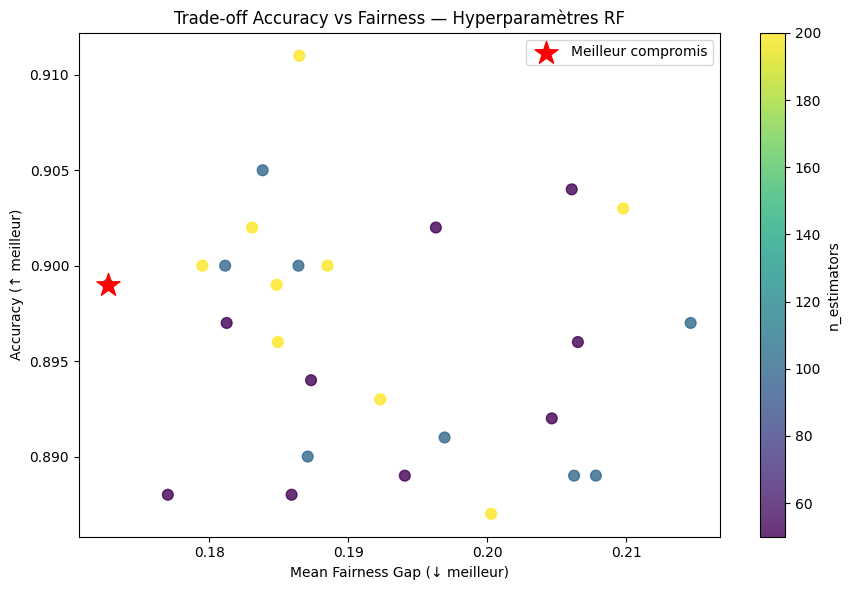

In [5]:
# Cellule 5: Analyser et visualiser les résultats
fairness_cols = ['delta_dp', 'delta_eo', 'delta_eqodds']
grid_df['mean_gap'] = grid_df[fairness_cols].mean(axis=1)
grid_df['composite_score'] = grid_df['accuracy'] - grid_df['mean_gap']

# Top 5 par accuracy
print('🏆 TOP 5 PAR ACCURACY:')
top_acc = grid_df.nlargest(5, 'accuracy')[['n_estimators','max_depth','min_samples_split','accuracy','mean_gap']]
print(top_acc.to_string(index=False))

# Top 5 par fairness
print('\n⚖️ TOP 5 PAR FAIRNESS (gap minimum):')
top_fair = grid_df.nsmallest(5, 'mean_gap')[['n_estimators','max_depth','min_samples_split','accuracy','mean_gap']]
print(top_fair.to_string(index=False))

# Meilleur compromis
best_row = grid_df.loc[grid_df['composite_score'].idxmax()]
print(f'\n🎯 MEILLEUR COMPROMIS ACCURACY/FAIRNESS:')
print(f'  n_estimators={best_row["n_estimators"]}, max_depth={best_row["max_depth"]}, min_samples_split={best_row["min_samples_split"]}')
print(f'  Accuracy: {best_row["accuracy"]:.4f} | Mean Gap: {best_row["mean_gap"]:.4f}')

# Scatter accuracy vs fairness
plt.figure(figsize=(9, 6))
sc = plt.scatter(grid_df['mean_gap'], grid_df['accuracy'],
                 c=grid_df['n_estimators'], cmap='viridis', s=60, alpha=0.8)
plt.colorbar(sc, label='n_estimators')
plt.xlabel('Mean Fairness Gap (↓ meilleur)')
plt.ylabel('Accuracy (↑ meilleur)')
plt.title('Trade-off Accuracy vs Fairness — Hyperparamètres RF')
# Annoter le meilleur compromis
plt.scatter(best_row['mean_gap'], best_row['accuracy'], marker='*', s=300, c='red', label='Meilleur compromis', zorder=5)
plt.legend()
plt.tight_layout()
plt.savefig('rf_hyperparameter_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Cellule 6: Sauvegarder résultats
grid_df.to_csv('rf_hyperparameter_results.csv', index=False)

best_params = {
    'n_estimators':    int(best_row['n_estimators']),
    'max_depth':       None if best_row['max_depth'] == 'None' else int(best_row['max_depth']),
    'min_samples_split': int(best_row['min_samples_split']),
    'accuracy': float(best_row['accuracy']),
    'mean_fairness_gap': float(best_row['mean_gap']),
}
with open('best_rf_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print('💾 rf_hyperparameter_results.csv')
print('💾 best_rf_params.json')
print('🎉 Optimisation RF terminée!')


💾 rf_hyperparameter_results.csv
💾 best_rf_params.json
🎉 Optimisation RF terminée!
